In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_absolute_error
import utils
import torch
from torchmetrics.functional.regression import continuous_ranked_probability_score

Train a single ARIMA model on a single trajectory then sample (simulate) paths into the future and calculate the fraction of those laying witih 50, 95 CI

$$
i=0,1,2, ... N
\\
\{x(t)\}_i
\\
\{y(t)\} \sim ARIMA(p,d,q)
$$

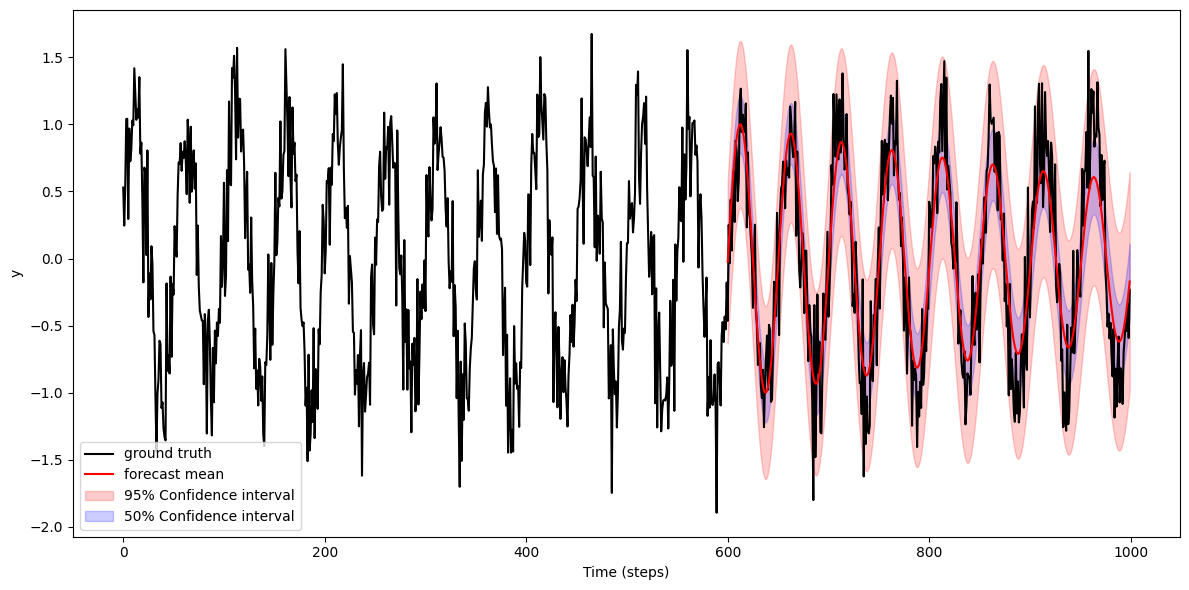

In [2]:
np.random.seed(0)

n = 1000
t = np.arange(n)
n_traj = 10000

signal = np.sin(2*np.pi*t/50) + 0.3*np.random.randn(n)
data=pd.Series(signal)

def generate(): 
    return np.sin(2*np.pi*t/50) + 0.3*np.random.randn(n)

split = 600

model = pm.auto_arima(data.iloc[:split], suppress_warnings=True)
result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci95 = forecast_res.conf_int(alpha=0.05)
ci95.index = test.index

trajs = []
for _ in range(n_traj):
    traj = generate()
    trajs.append(traj[split:])

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="ground truth")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

#for traj in trajs:
#    plt.plot(traj.index,traj,color="orange",alpha=0.5,label="Simulations" if n_traj == 1 else None)

plt.fill_between(ci95.index, ci95.iloc[:, 0], ci95.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")

plt.legend()
plt.tight_layout()
plt.show()


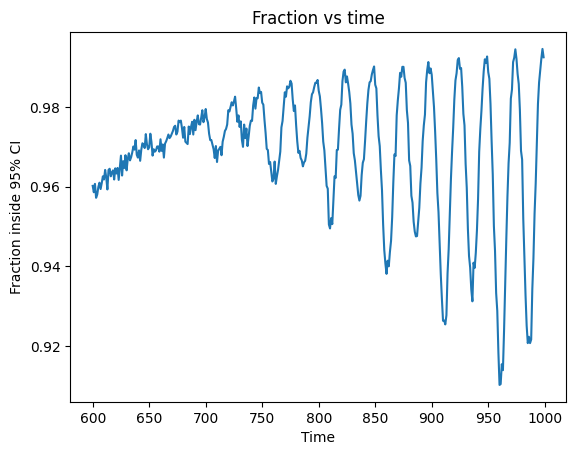

In [3]:
trajectories = torch.stack([torch.tensor(traj) for traj in trajs])
ci_lower = torch.tensor(ci95.iloc[:, 0].values)
ci_upper = torch.tensor(ci95.iloc[:, 1].values)

values=utils.fractionMetric(trajectories, ci_lower=ci_lower,ci_upper=ci_upper)

plt.plot(test.index, values)
plt.ylabel("Fraction inside 95% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

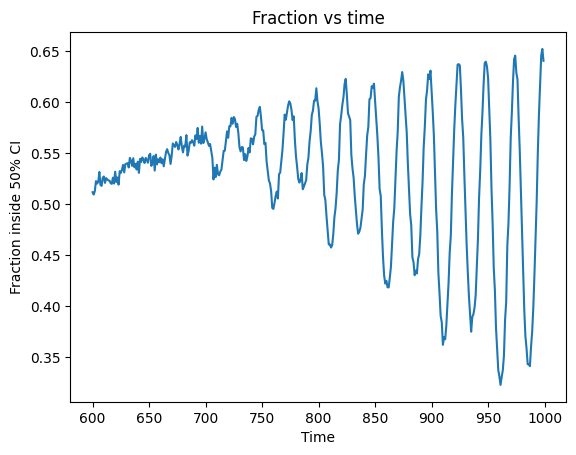

In [4]:
ci_lower = torch.tensor(ci50.iloc[:, 0].values, dtype=torch.float32)
ci_upper = torch.tensor(ci50.iloc[:, 1].values, dtype=torch.float32)

values=utils.fractionMetric(trajectories, ci_lower=ci_lower,ci_upper=ci_upper)

plt.plot(test.index, values)
plt.ylabel("Fraction inside 50% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

In [5]:
n_sim = 1000
sim_preds = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim_preds.append(torch.tensor(sim.values))

preds=torch.stack(sim_preds)
preds = preds.T    
target = torch.tensor(test.values)

crps_values = continuous_ranked_probability_score(preds, target)

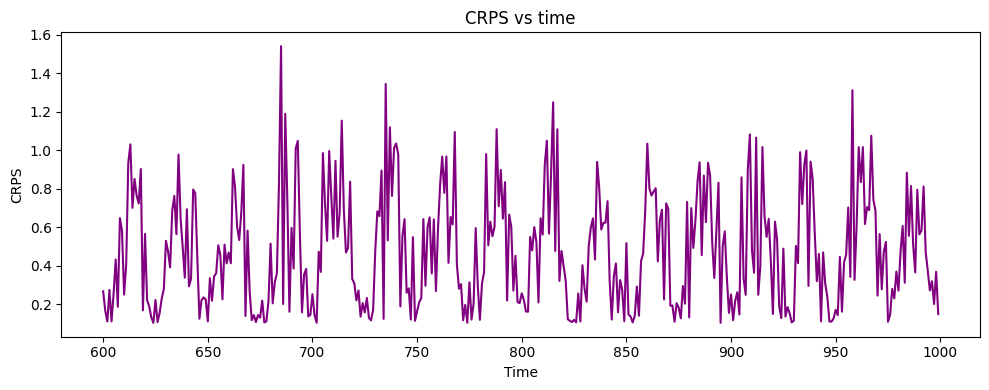

In [ ]:
crps_per_time=[]
for t in range(preds.shape[0]):
    crps_per_time.append(continuous_ranked_probability_score(preds[t].unsqueeze(0),target[t].unsqueeze(0)))
plt.figure(figsize=(10, 4))
plt.plot(test.index, crps_per_time, color="purple")
plt.xlabel("Time")
plt.ylabel("CRPS")
plt.title("CRPS vs time")
plt.tight_layout()
plt.show()

testing torchmetrics.functional.continuous_ranked_probability_score

$$
F(x)=\frac{1}{2}(1+ \text{erf}(\frac{x}{\sqrt{2}})) \\
crps(x)=\int_{-\infty}^{\infty}(F(z)-\mathbb{1}_{y\leq z})^2 dz   \\
       =\int_{-\infty}^{\infty} (\frac{1}{2}(1+ \text{erf}(\frac{z}{\sqrt{2}})) -\mathbb{1}_{y\leq z})^2 dz \\
$$

In [7]:
p=torch.stack([sim for sim in sim_preds])
q=torch.tensor(test.values)

crps=continuous_ranked_probability_score(p.T,q)
print(crps)

tensor(0.4743, dtype=torch.float64)


tensor(0.4744, dtype=torch.float64)


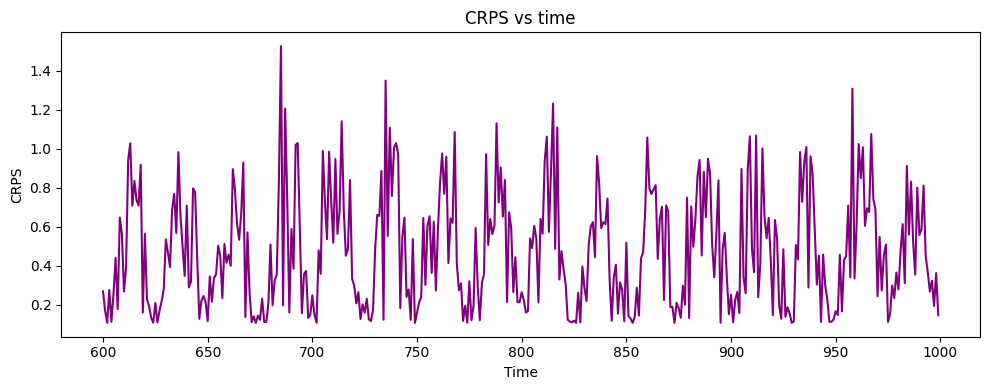

In [8]:
import math

mu = p.mean()
sigma = p.std()        
y = q

a = (y - mu) / sigma
phi = torch.exp(-0.5 * a**2)/math.sqrt(2 * math.pi)
Phi = 0.5*(1+torch.erf(a / math.sqrt(2)))
crps = sigma*(a*(2 * Phi - 1)+ 2 * phi-1 / math.sqrt(math.pi))
print(crps.mean())

plt.figure(figsize=(10, 4))
plt.plot(test.index, crps, color="purple")
plt.xlabel("Time")
plt.ylabel("CRPS")
plt.title("CRPS vs time")
plt.tight_layout()
plt.show()